In [1]:
import pandas as pd

columns = [
    "A1", "A2", "A3", "A4", "A5",
    "A6", "A7", "A8", "A9", "A10",
    "A11", "A12", "A13", "A14", "A15",
    "Class"
]

df = pd.read_csv(
    r"C:\Users\INDIA\Data-Science-and-Machine-Learning-\ml\supervised_machine_learning\KNN_Algoritham\datasets\credit\crx.data",
    header=None,
    names=columns,
    na_values="?"
)

print(df.head())

  A1     A2     A3 A4 A5 A6 A7    A8 A9 A10  A11 A12 A13    A14  A15 Class
0  b  30.83  0.000  u  g  w  v  1.25  t   t    1   f   g  202.0    0     +
1  a  58.67  4.460  u  g  q  h  3.04  t   t    6   f   g   43.0  560     +
2  a  24.50  0.500  u  g  q  h  1.50  t   f    0   f   g  280.0  824     +
3  b  27.83  1.540  u  g  w  v  3.75  t   t    5   t   g  100.0    3     +
4  b  20.17  5.625  u  g  w  v  1.71  t   f    0   f   s  120.0    0     +


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

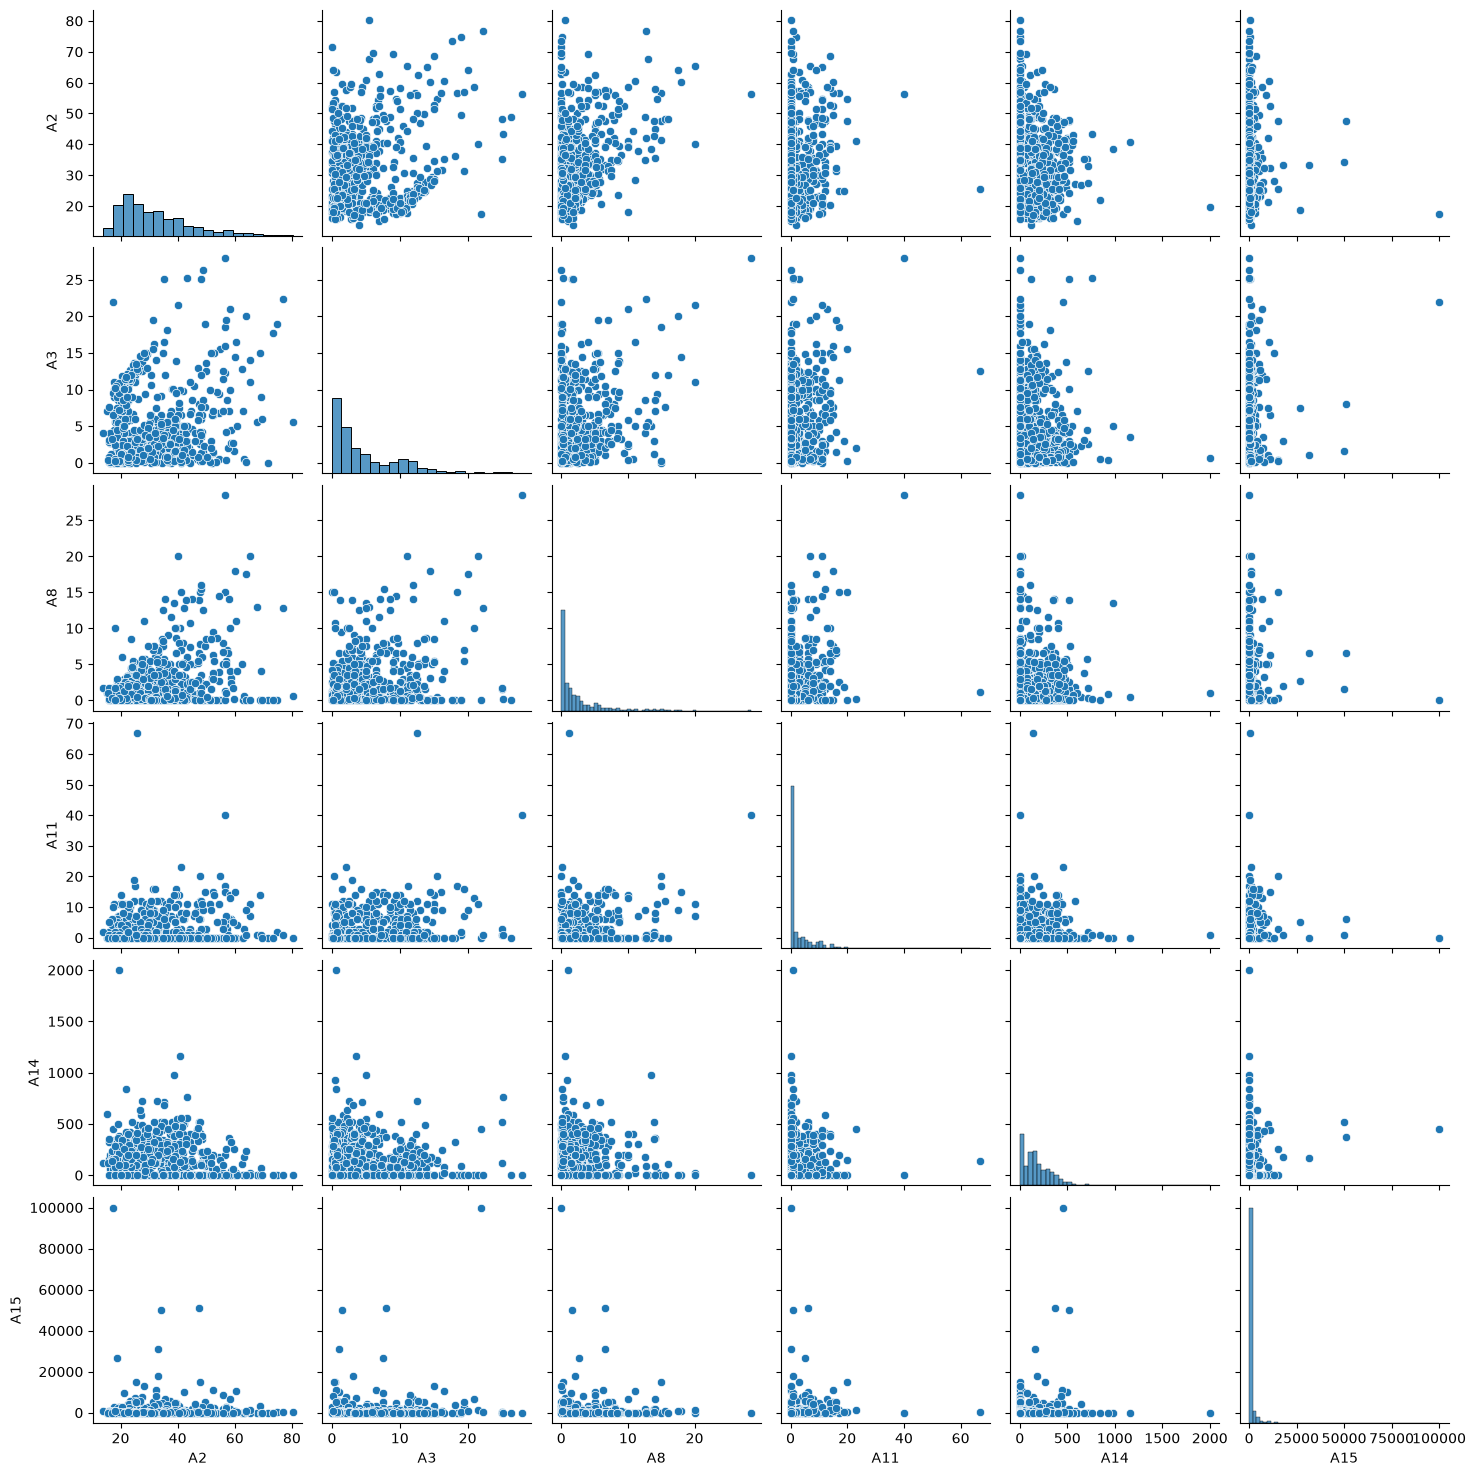

In [3]:
sns.pairplot(data=df)
plt.show()

<BarContainer object of 690 artists>

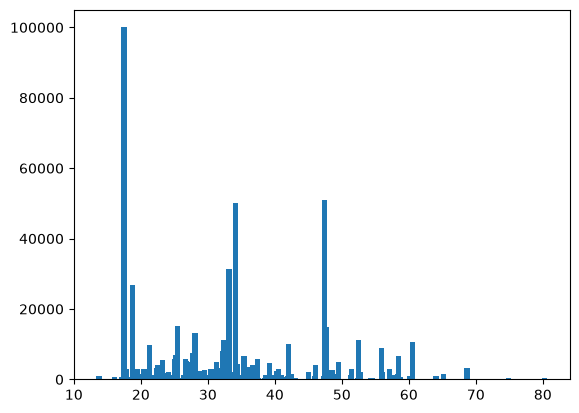

In [4]:
plt.bar(x=df['A2'],height=df['A15'])

In [6]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      678 non-null    str    
 1   A2      678 non-null    float64
 2   A3      690 non-null    float64
 3   A4      684 non-null    str    
 4   A5      684 non-null    str    
 5   A6      681 non-null    str    
 6   A7      681 non-null    str    
 7   A8      690 non-null    float64
 8   A9      690 non-null    str    
 9   A10     690 non-null    str    
 10  A11     690 non-null    int64  
 11  A12     690 non-null    str    
 12  A13     690 non-null    str    
 13  A14     677 non-null    float64
 14  A15     690 non-null    int64  
 15  Class   690 non-null    str    
dtypes: float64(4), int64(2), str(10)
memory usage: 86.4 KB
None


In [7]:
df.describe()

,A2,A3,A8,A11,A14,A15
count,678.000000,690.000000,690.000000,690.00000,677.000000,690.000000
mean,31.568171,4.758725,2.223406,2.40000,184.014771,1017.385507
std,11.957862,4.978163,3.346513,4.86294,173.806768,5210.102598
min,13.750000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,22.602500,1.000000,0.165000,0.00000,75.000000,0.000000
50%,28.460000,2.750000,1.000000,0.00000,160.000000,5.000000
75%,38.230000,7.207500,2.625000,3.00000,276.000000,395.500000
max,80.250000,28.000000,28.500000,67.00000,2000.000000,100000.000000


In [8]:
print(df.isnull().sum())

A1       12
A2       12
A3        0
A4        6
A5        6
A6        9
A7        9
A8        0
A9        0
A10       0
A11       0
A12       0
A13       0
A14      13
A15       0
Class     0
dtype: int64


In [9]:
print(df["Class"].value_counts())

Class
-    383
+    307
Name: count, dtype: int64


In [10]:
df.shape

(690, 16)

In [11]:
x=df.drop("Class",axis=1)
y=df["Class"]

In [12]:
print(x)

    A1     A2      A3 A4 A5  A6  A7    A8 A9 A10  A11 A12 A13    A14  A15
0    b  30.83   0.000  u  g   w   v  1.25  t   t    1   f   g  202.0    0
1    a  58.67   4.460  u  g   q   h  3.04  t   t    6   f   g   43.0  560
2    a  24.50   0.500  u  g   q   h  1.50  t   f    0   f   g  280.0  824
3    b  27.83   1.540  u  g   w   v  3.75  t   t    5   t   g  100.0    3
4    b  20.17   5.625  u  g   w   v  1.71  t   f    0   f   s  120.0    0
..  ..    ...     ... .. ..  ..  ..   ... ..  ..  ...  ..  ..    ...  ...
685  b  21.08  10.085  y  p   e   h  1.25  f   f    0   f   g  260.0    0
686  a  22.67   0.750  u  g   c   v  2.00  f   t    2   t   g  200.0  394
687  a  25.25  13.500  y  p  ff  ff  2.00  f   t    1   t   g  200.0    1
688  b  17.92   0.205  u  g  aa   v  0.04  f   f    0   f   g  280.0  750
689  b  35.00   3.375  u  g   c   h  8.29  f   f    0   t   g    0.0    0

[690 rows x 15 columns]


In [13]:
print(y)

0      +
1      +
2      +
3      +
4      +
      ..
685    -
686    -
687    -
688    -
689    -
Name: Class, Length: 690, dtype: str


In [14]:
df.isnull().sum()

A1       12
A2       12
A3        0
A4        6
A5        6
A6        9
A7        9
A8        0
A9        0
A10       0
A11       0
A12       0
A13       0
A14      13
A15       0
Class     0
dtype: int64

In [15]:
categorical_columns = [
    "A1", "A4", "A5", "A6", "A7",
    "A9", "A10", "A12", "A13"
]

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [16]:
df.isnull().sum()

A1        0
A2       12
A3        0
A4        0
A5        0
A6        0
A7        0
A8        0
A9        0
A10       0
A11       0
A12       0
A13       0
A14      13
A15       0
Class     0
dtype: int64

In [17]:
numeric_columns=[
    "A2","A3","A8","A11","A14","A15"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col],errors="coerce")
    df[col] = df[col].fillna(df[col].median())

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

In [22]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [23]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [25]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_columns),
    ("cat", categorical_pipeline, categorical_columns)
])

In [26]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_columns),
    ("cat", categorical_pipeline, categorical_columns)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])



In [29]:
from sklearn.model_selection import train_test_split

# Remove rows with a missing target and clean class labels
df = df.dropna(subset=["Class"]).copy()
df["Class"] = df["Class"].astype(str).str.strip()

x = df.drop(columns=["Class"])
y = df["Class"]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
model.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('knn', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['+','-']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['A1','A2','A3',...,'A13','A14','A15']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not

In [31]:
y_pred=model.predict(x_test)

In [32]:
print(y_pred[:10])

['-' '-' '+' '+' '-' '-' '-' '+' '-' '-']


In [33]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test,y_pred)
print(f"Accuracy is : {accuracy}")

Accuracy is : 0.8478260869565217


In [34]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           +       0.84      0.80      0.82        61
           -       0.85      0.88      0.87        77

    accuracy                           0.85       138
   macro avg       0.85      0.84      0.84       138
weighted avg       0.85      0.85      0.85       138



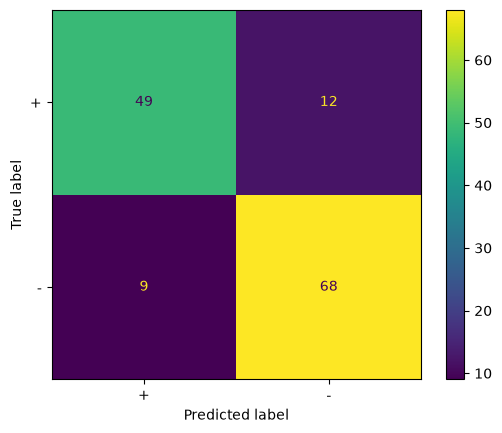

In [35]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

cm = confusion_matrix(y_test,y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()
plt.show()

In [37]:
for k in [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]:
    model = Pipeline(
        [
            ("preprocessor",preprocessor),
            ("knn",KNeighborsClassifier(n_neighbors=k))
        ]
    )

    model.fit(x_train,y_train)
    score_train = model.score(x_train,y_train)
    score=model.score(x_test,y_test)
    print(k,score," ",score_train)

1 0.7898550724637681   1.0
2 0.782608695652174   0.9329710144927537
3 0.8260869565217391   0.9021739130434783
4 0.7971014492753623   0.8913043478260869
5 0.8478260869565217   0.8876811594202898
6 0.8333333333333334   0.8804347826086957
7 0.8260869565217391   0.8876811594202898
8 0.8043478260869565   0.8876811594202898
9 0.8405797101449275   0.8931159420289855
10 0.8188405797101449   0.8913043478260869
11 0.8333333333333334   0.8894927536231884
12 0.8188405797101449   0.8931159420289855
13 0.8188405797101449   0.8804347826086957
14 0.8115942028985508   0.8858695652173914
15 0.8333333333333334   0.8804347826086957
